# Monte Carlo Integration

**Source:** https://labs.acme.byu.edu/Volume1/MonteCarloIntegration/MonteCarloIntegration.html

Monte Carlo integration estimates integrals by sampling random points. It converges at $O(N^{-1/2})$ regardless of dimension, making it uniquely effective for high-dimensional integrals where deterministic quadrature suffers the curse of dimensionality.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Basic Monte Carlo Integration

To estimate $\int_a^b f(x)\,dx$: draw $N$ uniform samples $x_i \sim U(a,b)$, then:
$$\int_a^b f(x)\,dx \approx (b-a) \cdot \frac{1}{N} \sum_{i=1}^N f(x_i)$$

The standard error is $\approx (b-a)\sqrt{\mathrm{Var}(f)/N}$.

In [2]:
rng = np.random.default_rng(42)

N = 100_000
x = rng.uniform(0, np.pi, N)
estimate = np.pi * np.mean(np.sin(x))

print(f"MC estimate ∫₀^π sin(x)dx = {estimate:.6f}")
print(f"Exact value = 2, error = {abs(estimate - 2):.6f}")

MC estimate ∫₀^π sin(x)dx = 2.001305
Exact value = 2, error = 0.001305


## 2. Estimating π via Monte Carlo

Sample points $(x,y) \in [-1,1]^2$. The fraction inside the unit circle ≈ π/4.

π ≈ 3.13656 (error: 0.00503)


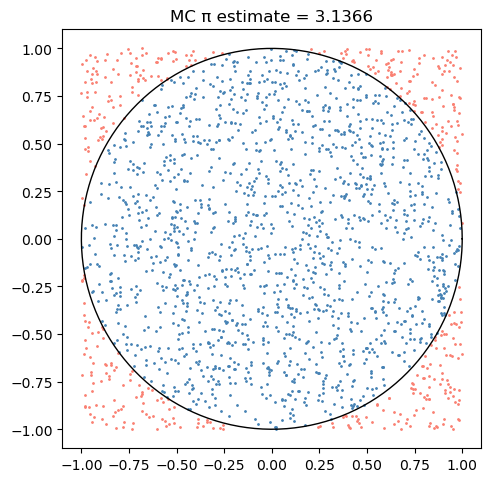

In [3]:
N = 50_000
pts = rng.uniform(-1, 1, (N, 2))
inside = (pts**2).sum(axis=1) <= 1
pi_est = 4 * inside.mean()
print(f"π ≈ {pi_est:.5f} (error: {abs(pi_est - np.pi):.5f})")

# Visualize
fig, ax = plt.subplots(figsize=(5, 5))

sample = pts[:2000]
in_s   = (sample**2).sum(axis=1) <= 1
ax.scatter(sample[in_s, 0],  sample[in_s, 1],  s=1, color='steelblue')
ax.scatter(sample[~in_s, 0], sample[~in_s, 1], s=1, color='salmon')
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=1)
ax.set_aspect('equal')
ax.set_title(f'MC π estimate = {pi_est:.4f}')
plt.tight_layout()
plt.show()

---

## Problem 1: Monte Carlo Integration in Multiple Dimensions

Estimate the volume of the unit ball in $d$ dimensions using MC sampling from $[-1,1]^d$.

In [4]:
def prob1(f, mins, maxs, N=100_000):
    """Monte Carlo integration of f over a hyperrectangle.
    
    Parameters
    ----------
    f    : callable — takes (N, d) array, returns (N,) values
    mins : array-like of lower bounds (length d)
    maxs : array-like of upper bounds (length d)
    N    : number of samples
    

    Returns
    -------
    estimate : float
    std_err  : float
    """
    mins, maxs = np.array(mins), np.array(maxs)
    d = len(mins)
    volume = np.prod(maxs - mins)
    pts = rng.uniform(0, 1, (N, d)) * (maxs - mins) + mins
    fvals = f(pts)
    estimate = volume * fvals.mean()
    std_err  = volume * fvals.std() / np.sqrt(N)
    return estimate, std_err


# Volume of unit ball in various dimensions
# True: V_d = π^(d/2) / Γ(d/2+1)
from scipy.special import gamma

for d in [2, 3, 4, 6, 8]:
    f = lambda pts: (pts**2).sum(axis=1) <= 1
    vol_est, err = prob1(f, [-1]*d, [1]*d, N=200_000)
    vol_true = np.pi**(d/2) / gamma(d/2 + 1)
    print(f"d={d}: MC={vol_est:.4f} ± {err:.4f}, True={vol_true:.4f}, error={abs(vol_est-vol_true):.4f}")

d=2: MC=3.1469 ± 0.0037, True=3.1416, error=0.0053
d=3: MC=4.1928 ± 0.0089, True=4.1888, error=0.0040
d=4: MC=4.9492 ± 0.0165, True=4.9348, error=0.0144
d=6: MC=5.1744 ± 0.0390, True=5.1677, error=0.0067
d=8: MC=4.0819 ± 0.0717, True=4.0587, error=0.0232


## Problem 2: Convergence Rate O(N^{-1/2})

Verify empirically that the MC error scales as $N^{-1/2}$.

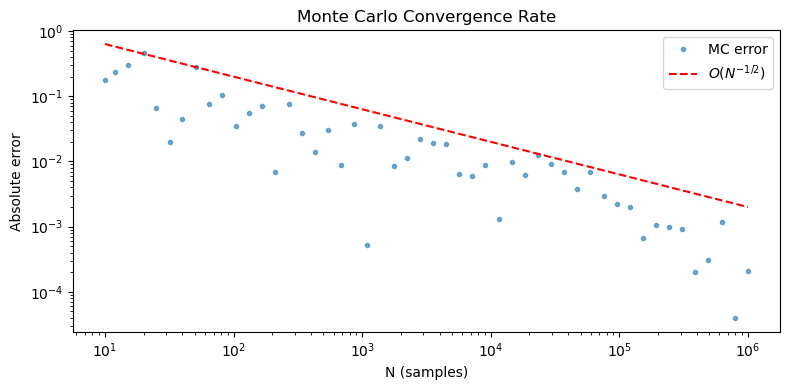

In [5]:
def prob2():
    """Plot MC error vs N on log-log scale; verify O(N^{-1/2}) rate."""
    true_val = 2.0   # ∫₀^π sin(x) dx
    N_vals = np.logspace(1, 6, 50).astype(int)
    errors = []
    
    for N in N_vals:
        x = rng.uniform(0, np.pi, N)
        est = np.pi * np.mean(np.sin(x))
        errors.append(abs(est - true_val))
    
    plt.figure(figsize=(8, 4))
    plt.loglog(N_vals, errors, '.', alpha=0.6, label='MC error')
    # Reference line N^{-1/2}
    N_ref = np.array([N_vals[0], N_vals[-1]], dtype=float)
    plt.loglog(N_ref, 2 * N_ref**-0.5, 'r--', label=r'$O(N^{-1/2})$')
    plt.xlabel('N (samples)')
    plt.ylabel('Absolute error')
    plt.title('Monte Carlo Convergence Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

prob2()

## Problem 3: Monte Carlo vs Quadrature in High Dimensions

Compare MC integration against scipy's `nquad` for increasing dimensions. MC's advantage: error is $O(N^{-1/2})$ independent of $d$.

In [6]:
from scipy.integrate import nquad

def prob3(d, N=100_000):
    """Compare MC vs scipy.nquad for integrating f(x)=exp(-||x||^2) over [-2,2]^d."""
    # MC estimate
    pts = rng.uniform(-2, 2, (N, d))
    fvals = np.exp(-(pts**2).sum(axis=1))
    vol = 4.0**d
    mc_est = vol * fvals.mean()
    mc_err = vol * fvals.std() / np.sqrt(N)
    
    # True value: (sqrt(pi) * erf(2))^d
    from scipy.special import erf
    true_val = (np.sqrt(np.pi) * erf(2))**d
    
    print(f"d={d}: MC={mc_est:.4f} ± {mc_err:.4f}, True={true_val:.4f}, error={abs(mc_est-true_val):.4f}")


for d in [1, 2, 3, 5, 8]:
    prob3(d)

d=1: MC=1.7623 ± 0.0044, True=1.7642, error=0.0019
d=2: MC=3.1278 ± 0.0124, True=3.1123, error=0.0155
d=3: MC=5.4650 ± 0.0310, True=5.4906, error=0.0255
d=5: MC=17.0802 ± 0.1686, True=17.0881, error=0.0078
d=8: MC=94.9309 ± 2.1024, True=93.8230, error=1.1079


## Problem 4: Importance Sampling

**Importance sampling** reduces variance by sampling from a distribution $g(x)$ that resembles $f(x)$:
$$\int f(x)\,dx = \int \frac{f(x)}{g(x)} g(x)\,dx \approx \frac{1}{N} \sum_{i=1}^N \frac{f(x_i)}{g(x_i)}, \quad x_i \sim g$$

Apply to estimate the tail probability $P(X > 4)$ for $X \sim N(0,1)$.

In [7]:
def prob4(N=100_000):
    """Estimate P(X>4) for X~N(0,1) via naive MC and importance sampling."""
    true_prob = 1 - stats.norm.cdf(4)
    
    # Naive MC: sample X~N(0,1), check X>4
    x_naive = rng.standard_normal(N)
    naive = (x_naive > 4).mean()
    naive_err = np.sqrt(true_prob * (1 - true_prob) / N)
    
    # Importance sampling: sample from N(4.5, 1) — centered near tail
    mu_g = 4.5
    x_is = rng.normal(mu_g, 1, N)
    # Importance weights: p(x)/g(x) = N(0,1)/N(4.5,1)
    log_w = stats.norm.logpdf(x_is) - stats.norm.logpdf(x_is, loc=mu_g)
    weights = np.exp(log_w)
    is_est = np.mean((x_is > 4) * weights)
    
    is_err = np.std((x_is > 4) * weights) / np.sqrt(N)
    
    print(f"True P(X>4):           {true_prob:.2e}")
    print(f"Naive MC:              {naive:.2e} ± {naive_err:.2e}")
    print(f"Importance Sampling:   {is_est:.2e} ± {is_err:.2e}")
    print(f"Variance ratio (IS/naive): {(is_err/naive_err)**2:.4f} (< 1 means IS is better)")

prob4()

True P(X>4):           3.17e-05
Naive MC:              0.00e+00 ± 1.78e-05
Importance Sampling:   3.14e-05 ± 2.21e-07
Variance ratio (IS/naive): 0.0002 (< 1 means IS is better)
